In [99]:
#312
#https://medium.com/p/e5720c052ee9
#https://github.com/alva922/Algo-Trading/blob/main/POLYFIT/polyfit_reg_pltr.py
#https://www.quantifiedstrategies.com/trend-following-strategy-by-industry/
#https://eodhd.com/cp/dashboard
#https://eodhd.com/financial-apis/quick-start-with-our-financial-data-apis
#616f12db969192.57240456
#698c3e871d5846.34864063 cosnkurs
#!pip install eodhd

In [100]:
eod="698c3e871d5846.34864063"

In [101]:
#https://medium.com/@alexzap922/a-polynomial-regression-based-trend-following-strategy-vs-market-backtesting-and-out-of-sample-e5720c052ee9?sk=9520ef5ad9cde1e1c520cc47ce9765e5
import os
#os.chdir(r'YOURPATH')    # Set working directory
#os. getcwd() 

#EODHD APIs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from eodhd import APIClient
import mplfinance as mpf

# --- PARAMETERS ---
symbol = "PLTR"
start_date = "2021-01-01"
end_date = "2026-01-31"


# --- DOWNLOAD PRICE DATA FROM EODHD ---

api = APIClient(eod)
#raw = client.get_end_of_day_historical_stock_market_data(symbol, start=start_date, end=end_date)

resp = api.get_eod_historical_stock_market_data(symbol = symbol, period='d', from_date = start_date, to_date = end_date, order='a')
dfvx = pd.DataFrame(resp)
#dfvx.tail()

data = pd.DataFrame(resp)
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)
data = data[['open', 'high', 'low', 'close','volume']].rename(columns=str.title)  # Align with OHLC naming
data.sort_index(inplace=True)

data.tail()
data.info()
data
# Plot candlesticks

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 244 entries, 2025-02-11 to 2026-01-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    244 non-null    float64
 1   High    244 non-null    float64
 2   Low     244 non-null    float64
 3   Close   244 non-null    float64
 4   Volume  244 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.4 KB


,Open,High,Low,Close,Volume
date,,,,,
2025-02-11,116.50000000,118.66000000,112.10000000,112.62000000,94311700
2025-02-12,110.29000000,117.59000000,110.00000000,117.39000000,75316900
2025-02-13,117.31000000,118.39000000,115.15000000,117.91000000,60027000
2025-02-14,117.90000000,120.67000000,116.80000000,119.16000000,65528900
2025-02-18,120.94000000,125.00000000,118.43000000,124.62000000,84227200
...,...,...,...,...,...
2026-01-26,168.21000000,170.58970000,167.32500000,167.47000000,22777160
2026-01-27,167.48000000,169.44000000,164.69000000,165.70000000,26542311
2026-01-28,164.40000000,165.04500000,157.24000000,157.35000000,44822848


In [102]:
#Yahoo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import mplfinance as mpf

# --- PARAMETERS ---
symbol = "PLTR"
start_date = "2021-01-01"
end_date = "2026-01-31"

# --- DOWNLOAD PRICE DATA FROM YFINANCE (FLAT COLUMNS) ---
data = yf.download(
    tickers=symbol,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,
    progress=False,
    group_by="column",
    multi_level_index=False,   # <-- key fix (prevents "Price/Ticker" header)
)

# Keep OHLCV only and enforce order
data = data[["Open", "High", "Low", "Close", "Volume"]].copy()

# Ensure index formatting matches your output
data.index = pd.to_datetime(data.index)
data.index.name = "date"
data.sort_index(inplace=True)

print(data.tail())
print(data.info())
data

                   Open         High          Low        Close    Volume
date                                                                    
2026-01-26 168.21000671 170.58999634 167.32499695 167.47000122  22777200
2026-01-27 167.47999573 169.44000244 164.69000244 165.69999695  26542300
2026-01-28 164.39999390 165.04499817 157.24000549 157.35000610  44822800
2026-01-29 157.63000488 157.63000488 147.11999512 151.86000061  59846800
2026-01-30 150.05000305 151.00000000 145.13900757 146.58999634  47271000
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1275 entries, 2021-01-04 to 2026-01-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1275 non-null   float64
 1   High    1275 non-null   float64
 2   Low     1275 non-null   float64
 3   Close   1275 non-null   float64
 4   Volume  1275 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.8 KB
None


,Open,High,Low,Close,Volume
date,,,,,
2021-01-04,23.90999985,24.50000000,22.50000000,23.37000084,44970400
2021-01-05,23.18000031,24.67000008,22.88999939,24.60000038,29050400
2021-01-06,24.12000084,24.45999908,23.25000000,23.54000092,32732900
2021-01-07,24.02000046,25.19000053,23.67000008,25.00000000,32240000
2021-01-08,25.70000076,26.44000053,24.70000076,25.20000076,41313800
...,...,...,...,...,...
2026-01-26,168.21000671,170.58999634,167.32499695,167.47000122,22777200
2026-01-27,167.47999573,169.44000244,164.69000244,165.69999695,26542300
2026-01-28,164.39999390,165.04499817,157.24000549,157.35000610,44822800


C:\Users\cosn\anaconda3\envs\python312\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


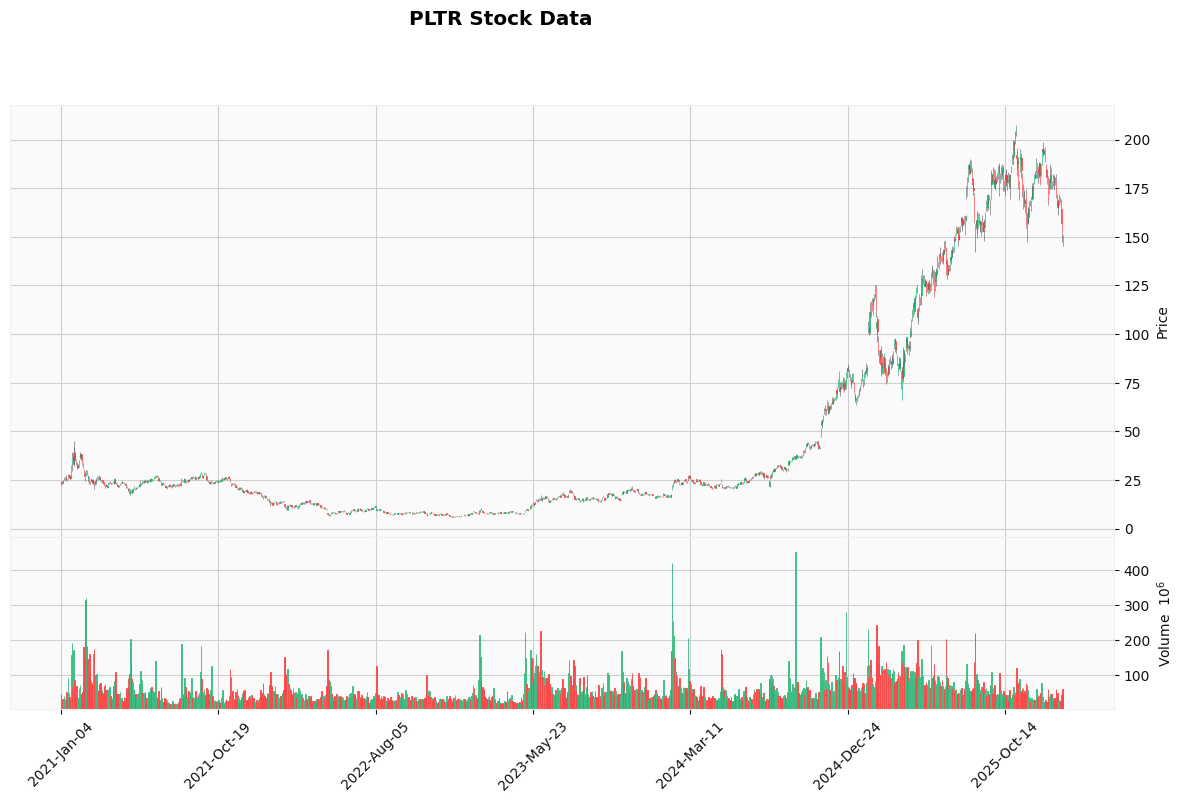

,date,open,high,low,close,adjusted_close,volume,warning
239,2026-01-26,168.21000000,170.58970000,167.32500000,167.47000000,167.47000000,22777160,NaN
240,2026-01-27,167.48000000,169.44000000,164.69000000,165.70000000,165.70000000,26542311,NaN
241,2026-01-28,164.40000000,165.04500000,157.24000000,157.35000000,157.35000000,44822848,NaN
242,2026-01-29,157.63000000,157.63000000,147.12000000,151.86000000,151.86000000,59846809,NaN
243,2026-01-30,150.05000000,151.00000000,145.13900000,146.59000000,146.59000000,47271039,Data is limited by one year as you have free s...


In [103]:
# Plot candlesticks
mpf.plot(
    data,
    type='candle',
    volume=True,
    title='PLTR Stock Data', figratio=(16, 9),figscale=1.5,
    style='yahoo'
)
datal = pd.DataFrame(resp)
datal['date'] = pd.to_datetime(datal['date'])

datal.tail()


C:\Users\cosn\anaconda3\envs\python312\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


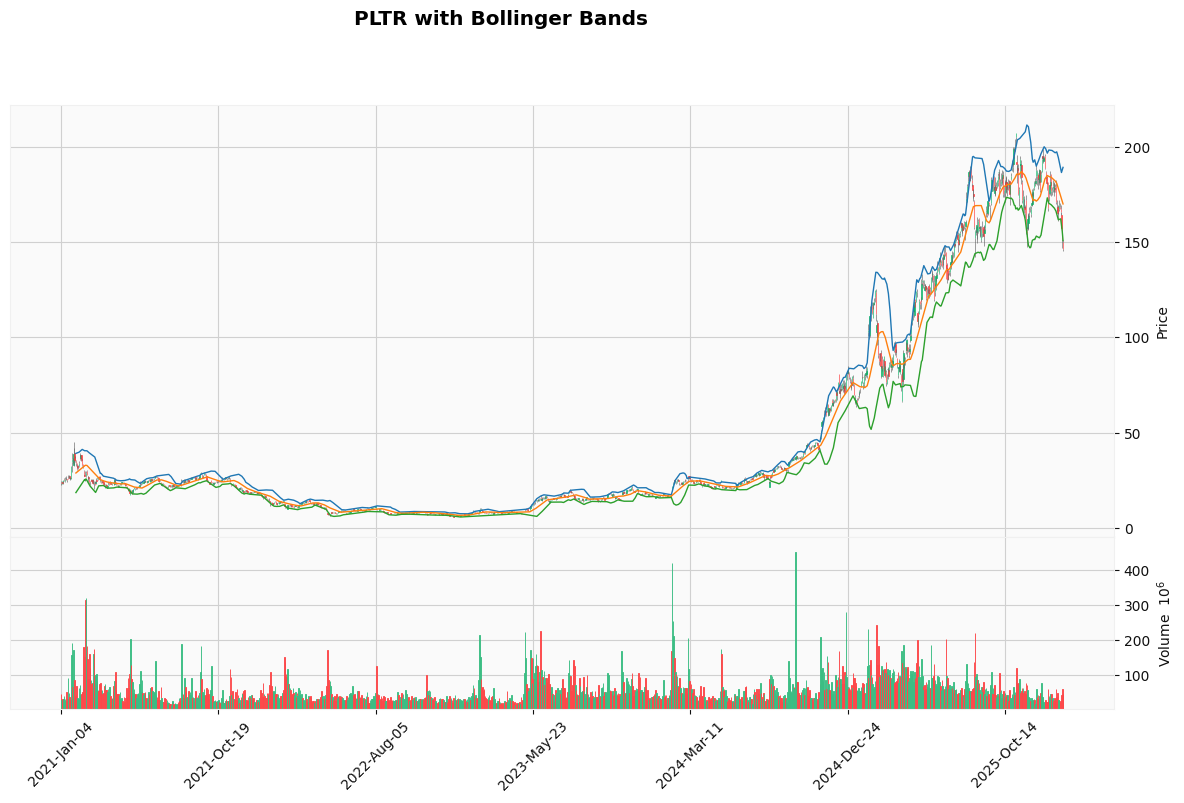

In [104]:
def plot_candles_with_bollinger(data, title="Chart", period=20, std=2):

    df = data.copy()
    df.index = pd.to_datetime(df.index)

    # Bollinger Bands
    df['bb_middle'] = df['Close'].rolling(period).mean()
    df['bb_std'] = df['Close'].rolling(period).std()
    df['bb_upper'] = df['bb_middle'] + std * df['bb_std']
    df['bb_lower'] = df['bb_middle'] - std * df['bb_std']

    apds = [
        mpf.make_addplot(df['bb_upper'], width=1),
        mpf.make_addplot(df['bb_middle'], width=1),
        mpf.make_addplot(df['bb_lower'], width=1),
    ]

    mpf.plot(
        df,
        type='candle',
        volume=True,
        addplot=apds,
        title=title,
        figratio=(16, 9),
        figscale=1.5,
        style='yahoo'
    )

plot_candles_with_bollinger(data, "PLTR with Bollinger Bands")

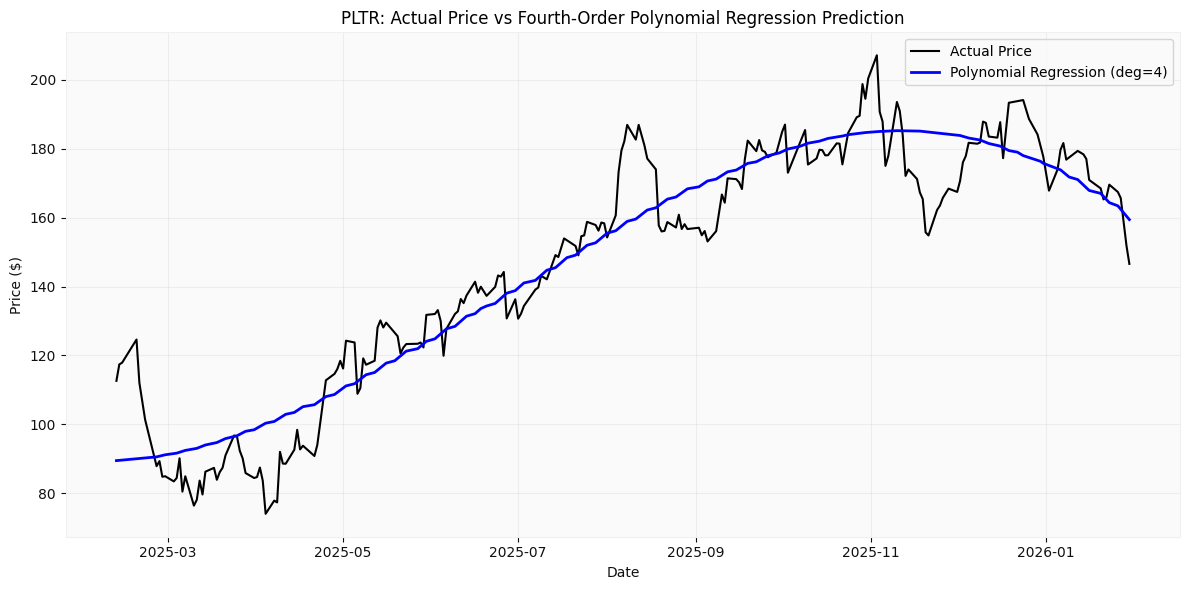

In [105]:


#Polynomial Regression: N-Order

df=datal.copy()
N=3

import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Time index
df["t"] = np.arange(len(df))

X = df[["t"]]
y = df["close"]

poly = PolynomialFeatures(degree=N)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

df["poly_fit"] = model.predict(X_poly)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Actual prices
plt.plot(df["date"], df["close"],
         label="Actual Price",
         color="black",
         linewidth=1.5)

# Polynomial predictions
plt.plot(df["date"], df["poly_fit"],
         label="Polynomial Regression (deg=4)",
         color="blue",
         linewidth=2)



plt.title("PLTR: Actual Price vs Fourth-Order Polynomial Regression Prediction")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [106]:
from sklearn.metrics import r2_score
y_test=df["close"]
y_preds=df["poly_fit"]
r2=r2_score(y_test, y_preds)
r2

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_preds)
mae

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,
y_preds)
rmse=np.sqrt(mse)
rmse

from sklearn.metrics import mean_absolute_percentage_error
mape=mean_absolute_percentage_error(y_test, y_preds)
mape


#Expanding Window Regression without Lookahead

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Assume df has a 'close' column
window = None  # Expanding window; use an integer for rolling window
degree = 3     # Cubic regression

# Store regression predictions
df["poly_fit"] = np.nan

for i in range(3, len(df)):
    if window:
        start = max(0, i-window)
    else:
        start = 0  # expanding window

    X = np.arange(start, i).reshape(-1, 1)
    y = df["close"].iloc[start:i].values

    # Fit cubic regression
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly, y)

    # Predict for current point only
    X_current = poly.transform(np.array([[i]]))
    df.at[i, "poly_fit"] = model.predict(X_current)

# Calculate slope
df["reg_slope"] = df["poly_fit"].diff()

# Entry & exit signals
df["reg_long_signal"] = (df["close"] > df["poly_fit"]) & (df["reg_slope"] > 0)
df["position"] = df["reg_long_signal"].astype(int)
df["entry"] = (df["position"] == 1) & (df["position"].shift(1) == 0)
df["exit"] = (df["position"] == 0) & (df["position"].shift(1) == 1)
df.to_excel("output.xlsx", index=False)

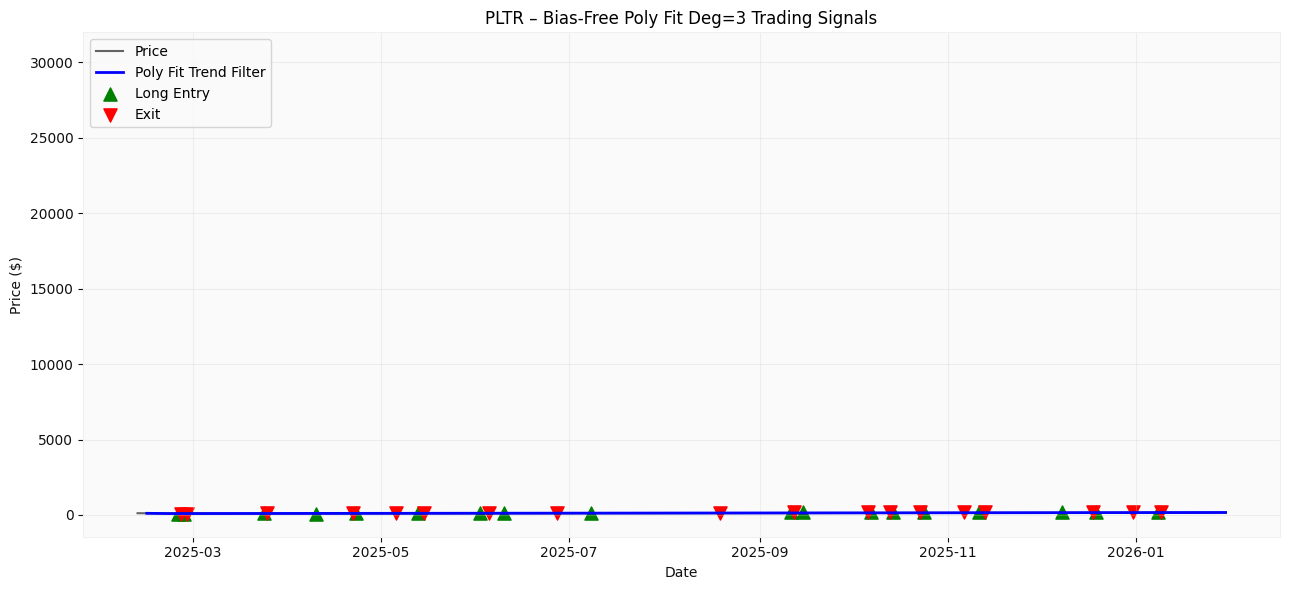

In [107]:




#Plot Trading Signals

import matplotlib.pyplot as plt

plt.figure(figsize=(13, 6))

# Price
plt.plot(df["date"], df["close"],
         label="Price",
         color="black",
         linewidth=1.5,alpha=0.6)

# Laplace filter
plt.plot(df["date"], df["poly_fit"],
         label="Poly Fit Trend Filter",
         color="blue",
         linewidth=2)

# Entry signals
plt.scatter(df.loc[df["entry"], "date"],
            df.loc[df["entry"], "close"],
            marker="^",
            color="green",
            s=90,
            label="Long Entry")

# Exit signals
plt.scatter(df.loc[df["exit"], "date"],
            df.loc[df["exit"], "close"],
            marker="v",
            color="red",
            s=90,
            label="Exit")

# Highlight time in position
plt.fill_between(
    df["date"],
    df["close"].min(),
    df["close"].max(),
    where=df["position"] == 1,
    color="green",
    alpha=0.08,
    transform=plt.gca().get_xaxis_transform(),
    #label="In Position"
)

plt.title("PLTR – Bias-Free Poly Fit Deg=3 Trading Signals")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [125]:


# Transaction cost per trade
transaction_cost = 0.001  # 0.1% per trade

# Compute daily returns
df["daily_return"] = df["close"].pct_change().fillna(0)

# Build position from entry/exit signals
df["position_from_signals"] = 0
for i in range(1, len(df)):
    if df.at[i, "entry"]:
        df.at[i, "position_from_signals"] = 1
    elif df.at[i, "exit"]:
        df.at[i, "position_from_signals"] = 0
    else:
        df.at[i, "position_from_signals"] = df.at[i - 1, "position_from_signals"]

# Strategy daily returns
df["strategy_return"] = df["daily_return"] * df["position_from_signals"]

# Detect trades for transaction costs
df["trade"] = df["entry"].astype(int) + df["exit"].astype(int)

# Apply transaction costs
df["strategy_return_tc"] = df["strategy_return"] - df["trade"] * transaction_cost

# Cumulative returns
df["cum_strategy"] = (1 + df["strategy_return"]).cumprod()
df["cum_strategy_tc"] = (1 + df["strategy_return_tc"]).cumprod()
df["cum_buy_hold"] = (1 + df["daily_return"]).cumprod()
df.to_excel("output_trans.xlsx", index=False)

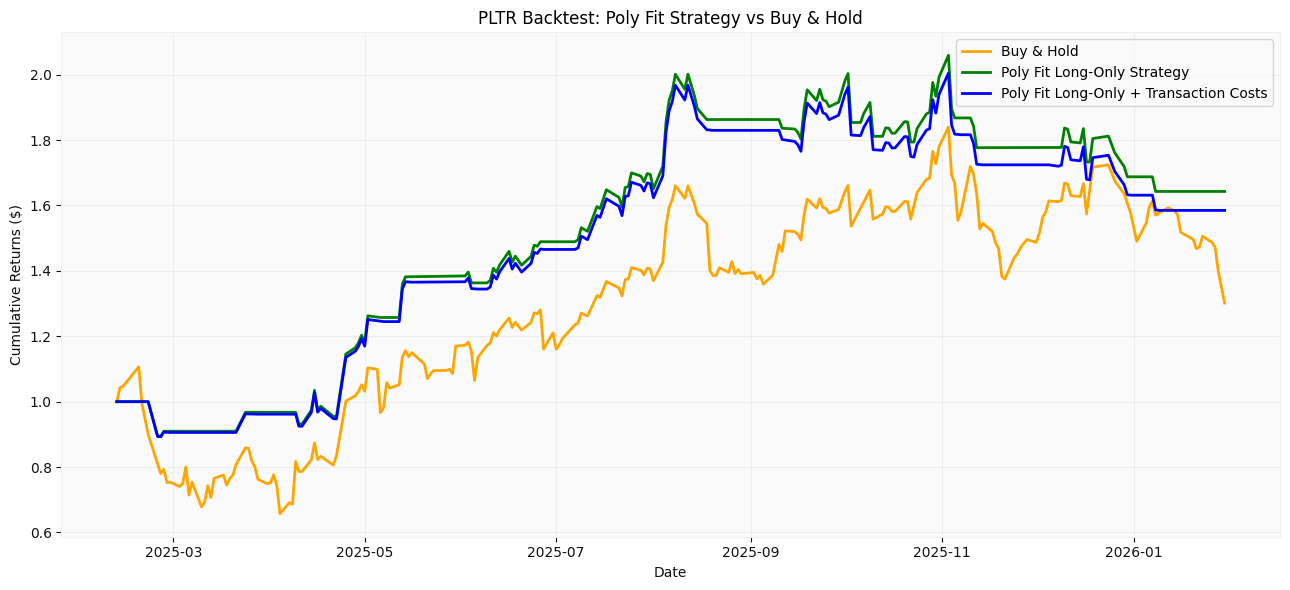

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 6))

plt.plot(df["date"], df["cum_buy_hold"],
         label="Buy & Hold",
         color="orange",
         linewidth=2)

plt.plot(df["date"], df["cum_strategy"],
         label="Poly Fit Long-Only Strategy",
         color="green",
         linewidth=2)

plt.plot(df["date"], df["cum_strategy_tc"],
         label="Poly Fit Long-Only + Transaction Costs",
         color="blue",
         linewidth=2)

plt.title("PLTR Backtest: Poly Fit Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [129]:



# --- Total Return ---
total_return_strategy = df["cum_strategy_tc"].iloc[-1] - 1
total_return_bh = df["cum_buy_hold"].iloc[-1] - 1

# --- CAGR / Annualized Return ---
days = len(df)
annual_factor = 252 / days
cagr_strategy = (1 + total_return_strategy) ** annual_factor - 1
cagr_bh = (1 + total_return_bh) ** annual_factor - 1

# --- Annualized Volatility ---
vol_strategy = df["strategy_return_tc"].std() * np.sqrt(252)
vol_bh = df["daily_return"].std() * np.sqrt(252)

# --- Sharpe Ratio (assume rf=0) ---
sharpe_strategy = cagr_strategy / vol_strategy
sharpe_bh = cagr_bh / vol_bh

# --- Max Drawdown ---
def max_drawdown(cum_returns):
    roll_max = cum_returns.cummax()
    drawdown = (cum_returns - roll_max) / roll_max
    return drawdown.min()

mdd_strategy = max_drawdown(df["cum_strategy_tc"])
mdd_bh = max_drawdown(df["cum_buy_hold"])

# --- Print results ---
print("=== Strategy Performance Metrics ===")
print(f"Total Return: {total_return_strategy:.2%}")
print(f"CAGR: {cagr_strategy:.2%}")
print(f"Annualized Volatility: {vol_strategy:.2%}")
print(f"Sharpe Ratio: {sharpe_strategy:.2f}")
print(f"Max Drawdown: {mdd_strategy:.2%}")

print("\n=== Buy & Hold Metrics ===")
print(f"Total Return: {total_return_bh:.2%}")
print(f"CAGR: {cagr_bh:.2%}")
print(f"Annualized Volatility: {vol_bh:.2%}")
print(f"Sharpe Ratio: {sharpe_bh:.2f}")
print(f"Max Drawdown: {mdd_bh:.2%}")

# Identify trades
trades = df[df["position"].diff().abs() == 1].index

trade_returns = []

for i in range(0, len(trades), 2):
    entry = trades[i]
    exit_ = trades[i+1] if i+1 < len(trades) else len(df)-1
    trade_ret = (df["close"].iloc[exit_] / df["close"].iloc[entry]) - 1
    trade_returns.append(trade_ret)

trade_returns = np.array(trade_returns)
win_rate = np.mean(trade_returns > 0)
avg_trade_ret = np.mean(trade_returns)

print(f"Number of Trades: {len(trade_returns)}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Average Trade Return: {avg_trade_ret:.2%}")

#Out-of-Sample (OOS)

split_ratio = 0.9
split_index = int(len(df) * split_ratio)

# In-sample
df_is = df.iloc[:split_index].copy()

# Out-of-sample
df_oos = df.iloc[split_index:].copy()

=== Strategy Performance Metrics ===
Total Return: 58.49%
CAGR: 60.91%
Annualized Volatility: 34.56%
Sharpe Ratio: 1.76
Max Drawdown: -20.94%

=== Buy & Hold Metrics ===
Total Return: 30.16%
CAGR: 31.29%
Annualized Volatility: 61.46%
Sharpe Ratio: 0.51
Max Drawdown: -40.61%
Number of Trades: 18
Win Rate: 50.00%
Average Trade Return: -0.32%


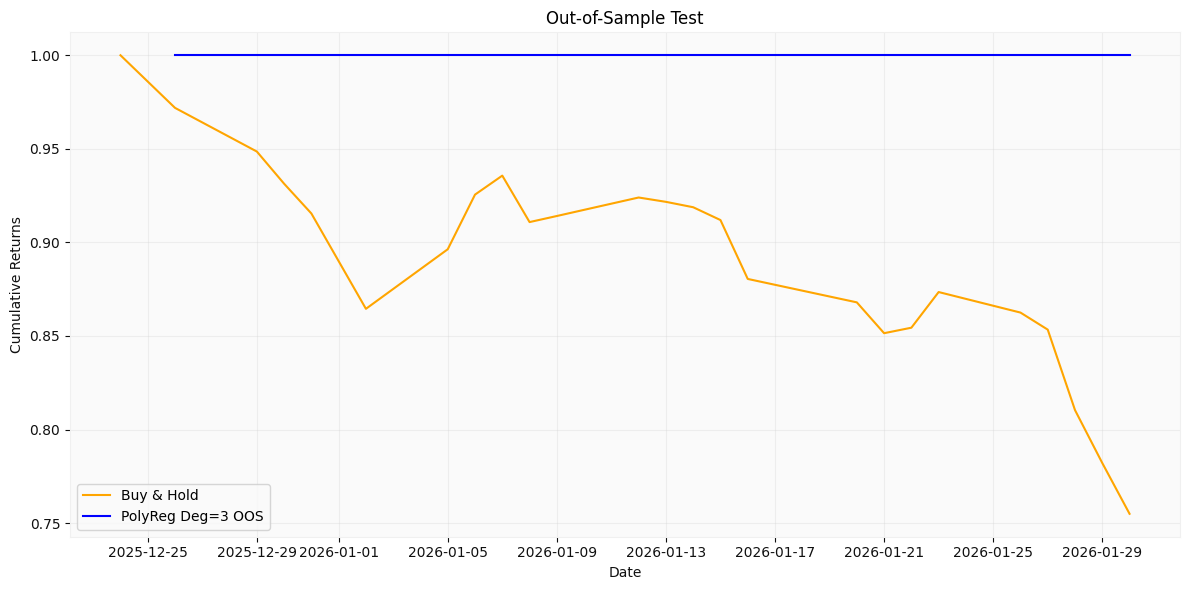

=== Strategy Performance Metrics ===
Total Return: 0.00%
CAGR: 0.00%
Annualized Volatility: 0.00%
Sharpe Ratio: nan
Max Drawdown: 0.00%

=== Buy & Hold Metrics ===
Total Return: -24.50%
CAGR: -25.20%
Annualized Volatility: 37.00%
Sharpe Ratio: -0.68
Max Drawdown: -24.50%


C:\Users\cosn\AppData\Local\Temp\ipykernel_18716\72971867.py:71: RuntimeWarning: invalid value encountered in scalar divide
  sharpe_strategy = cagr_strategy / vol_strategy


In [131]:


import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Time index
df_oos["t"] = np.arange(len(df_oos))

X = df_oos[["t"]]
y = df_oos["close"]

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

df_oos["poly_fit"] = model.predict(X_poly)


# Compute slope for entry/exit
df_oos["reg_slope"] = df_oos["poly_fit"].diff()

# Entry & exit rules
df_oos["reg_long_signal"] = (
    (df_oos["close"] > df_oos["poly_fit"]) &
    (df_oos["reg_slope"] > 0)
)

df_oos["position"] = df_oos["reg_long_signal"].astype(int)

transaction_cost = 0.001
df_oos["daily_return"] = df_oos["close"].pct_change().fillna(0)
df_oos["strategy_return"] = df_oos["daily_return"] * df_oos["position"]

# Detect trades
df_oos["trade"] = df_oos["position"].diff().abs()
df_oos["strategy_return"] -= df_oos["trade"] * transaction_cost

# Cumulative returns
df_oos["cum_strategy"] = (1 + df_oos["strategy_return"]).cumprod()
df_oos["cum_buy_hold"] = (1 + df_oos["daily_return"]).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_oos["date"], df_oos["cum_buy_hold"], label="Buy & Hold", color="orange")
plt.plot(df_oos["date"], df_oos["cum_strategy"], label="PolyReg Deg=3 OOS", color="blue")
plt.title("Out-of-Sample Test")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Total Return ---
total_return_strategy = df_oos["cum_strategy"].iloc[-1] - 1
total_return_bh = df_oos["cum_buy_hold"].iloc[-1] - 1

# --- CAGR / Annualized Return ---
days = len(df)
annual_factor = 252 / days
cagr_strategy = (1 + total_return_strategy) ** annual_factor - 1
cagr_bh = (1 + total_return_bh) ** annual_factor - 1

# --- Annualized Volatility ---
vol_strategy = df_oos["strategy_return"].std() * np.sqrt(252)
vol_bh = df_oos["daily_return"].std() * np.sqrt(252)

# --- Sharpe Ratio (assume rf=0) ---
sharpe_strategy = cagr_strategy / vol_strategy
sharpe_bh = cagr_bh / vol_bh

# --- Max Drawdown ---
def max_drawdown(cum_returns):
    roll_max = cum_returns.cummax()
    drawdown = (cum_returns - roll_max) / roll_max
    return drawdown.min()

mdd_strategy = max_drawdown(df_oos["cum_strategy"])
mdd_bh = max_drawdown(df_oos["cum_buy_hold"])

# --- Print results ---
print("=== Strategy Performance Metrics ===")
print(f"Total Return: {total_return_strategy:.2%}")
print(f"CAGR: {cagr_strategy:.2%}")
print(f"Annualized Volatility: {vol_strategy:.2%}")
print(f"Sharpe Ratio: {sharpe_strategy:.2f}")
print(f"Max Drawdown: {mdd_strategy:.2%}")

print("\n=== Buy & Hold Metrics ===")
print(f"Total Return: {total_return_bh:.2%}")
print(f"CAGR: {cagr_bh:.2%}")
print(f"Annualized Volatility: {vol_bh:.2%}")
print(f"Sharpe Ratio: {sharpe_bh:.2f}")
print(f"Max Drawdown: {mdd_bh:.2%}")

In [ ]:
#https://medium.com/insiderfinance/the-unexpected-profitability-of-adaptive-local-linear-regression-in-short-term-trend-following-8f5643b3df96
#https://medium.com/@alexzap922/evaluating-a-laplace-trend-strength-strategy-using-backtesting-and-out-of-sample-tests-evidence-6819cdeae06f